# Imports

In [ ]:
pip install compressai -q

In [ ]:
!pip install --upgrade numpy

In [2]:
import math
import json
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
import requests

import torch
import torch.nn.functional as F
from torchvision.transforms import ToTensor, ToPILImage

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from kornia.losses import PSNRLoss, SSIMLoss
from torchmetrics.image import VisualInformationFidelity

from compressai.zoo import cheng2020_anchor, cheng2020_attn


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


ROOT = Path(".")
DATA_DIR = ROOT / "data" / "kodak"
OUT_DIR = ROOT / "outputs"
RECON_DIR = OUT_DIR / "reconstructions"
METRICS_DIR = OUT_DIR / "metrics"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RECON_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

KODAK_BASE_URL = "https://r0k.us/graphics/kodak/kodak"
QUALITY_LEVELS = [1, 3, 6]
METRIC = "mse"
PAD_MULTIPLE = 64 
SAVE_RECONSTRUCTIONS = True

Using device: cuda


In [3]:
def download_file(url: str, dst: Path):
    if dst.exists():
        return
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(dst, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

failed = []
for i in range(1, 25):
    fname = f"kodim{i:02d}.png"
    url = f"{KODAK_BASE_URL}/{fname}"
    dst = DATA_DIR / fname
    try:
        download_file(url, dst)
        print(f"Downloaded: {fname}")
    except Exception as e:
        failed.append((fname, str(e)))
        print(f"Failed: {fname} -> {e}")

print("\nDownloaded files:", len(list(DATA_DIR.glob('*.png'))))
if failed:
    print("\nFailures:")
    for item in failed:
        print(item)

Downloaded: kodim01.png
Downloaded: kodim02.png
Downloaded: kodim03.png
Downloaded: kodim04.png
Downloaded: kodim05.png
Downloaded: kodim06.png
Downloaded: kodim07.png
Downloaded: kodim08.png
Downloaded: kodim09.png
Downloaded: kodim10.png
Downloaded: kodim11.png
Downloaded: kodim12.png
Downloaded: kodim13.png
Downloaded: kodim14.png
Downloaded: kodim15.png
Downloaded: kodim16.png
Downloaded: kodim17.png
Downloaded: kodim18.png
Downloaded: kodim19.png
Downloaded: kodim20.png
Downloaded: kodim21.png
Downloaded: kodim22.png
Downloaded: kodim23.png
Downloaded: kodim24.png

Downloaded files: 24


In [4]:
def load_image_as_tensor(path: Path) -> torch.Tensor:
    """
    Returns tensor in shape [1, 3, H, W], float32, range [0,1]
    """
    img = Image.open(path).convert("RGB")
    x = ToTensor()(img).unsqueeze(0)
    return x

def count_bytes_in_strings(strings_obj):
    """
    CompressAI compress() returns nested lists of byte strings.
    This function recursively sums total bytes.
    """
    if isinstance(strings_obj, (bytes, bytearray)):
        return len(strings_obj)
    if isinstance(strings_obj, str):
        return len(strings_obj.encode("utf-8"))
    if isinstance(strings_obj, (list, tuple)):
        return sum(count_bytes_in_strings(s) for s in strings_obj)
    raise TypeError(f"Unsupported type in strings_obj: {type(strings_obj)}")

def tensor_to_uint8_np(x: torch.Tensor) -> np.ndarray:
    """
    Input [1,3,H,W] or [3,H,W] in [0,1]
    Output HxWx3 uint8
    """
    if x.ndim == 4:
        x = x[0]
    x = x.detach().cpu().clamp(0, 1)
    x = (x.permute(1, 2, 0).numpy() * 255.0).round().astype(np.uint8)
    return x

def compute_psnr_ssim(x_true: torch.Tensor, x_hat: torch.Tensor):
    """
    Both tensors in [1,3,H,W], range [0,1]
    """
    img_true = tensor_to_uint8_np(x_true)
    img_hat = tensor_to_uint8_np(x_hat)

    psnr = peak_signal_noise_ratio(img_true, img_hat, data_range=255)
    ssim = structural_similarity(
        img_true,
        img_hat,
        channel_axis=2,
        data_range=255
    )
    return float(psnr), float(ssim)

def save_reconstruction(x_hat: torch.Tensor, save_path: Path):
    save_path.parent.mkdir(parents=True, exist_ok=True)
    img = ToPILImage()(x_hat.squeeze(0).cpu().clamp(0, 1))
    img.save(save_path)

def list_kodak_images(data_dir: Path):
    imgs = sorted(data_dir.glob("kodim*.png"))
    assert len(imgs) == 24, f"Expected 24 Kodak images, found {len(imgs)}"
    return imgs

In [5]:
def load_compressai_model(model_name: str, quality: int, metric: str = "mse", device: str = "cpu"):
    from compressai.zoo import cheng2020_anchor, cheng2020_attn, mbt2018_mean, bmshj2018_hyperprior
    
    if "cheng2020-anchor" in model_name:
        model = cheng2020_anchor(quality=quality, metric=metric, pretrained=True)
    elif "cheng2020-attn" in model_name:
        model = cheng2020_attn(quality=quality, metric=metric, pretrained=True)
    elif "tcm" in model_name:
        model = mbt2018_mean(quality=quality, metric=metric, pretrained=True)
    elif "task" in model_name:
        model = bmshj2018_hyperprior(quality=quality, metric=metric, pretrained=True)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model = model.eval().to(device)
    if hasattr(model, "update"):
        model.update(force=True)
    return model

In [6]:
@torch.no_grad()
def evaluate_one_image(model, image_path, model_name, quality, device="cpu"):
    x = load_image_as_tensor(image_path).to(device)
    _, _, h, w = x.shape

    if not isinstance(model, str):
        p = 64
        new_h = (h + p - 1) // p * p
        new_w = (w + p - 1) // p * p
        x_padded = F.pad(x, (0, new_w - w, 0, new_h - h), mode="reflect")

        out_enc = model.compress(x_padded)
        total_bytes = count_bytes_in_strings(out_enc["strings"])
        
        out_forward = model(x_padded)
        x_hat = out_forward["x_hat"][:, :, :h, :w].clamp(0, 1)
    
    else:
        img_pil = Image.open(image_path).convert("RGB")
        buf = io.BytesIO()
        if model.lower() == "jpeg":
            img_pil.save(buf, format="JPEG", quality=quality)
        elif model.lower() in ["webp", "vvc_proxy"]:
            img_pil.save(buf, format="WEBP", quality=quality)
            
        total_bytes = buf.tell()
        buf.seek(0)
        x_hat = ToTensor()(Image.open(buf)).unsqueeze(0).to(device)

    bpp = (total_bytes * 8) / (h * w)
    psnr, ssim = compute_psnr_ssim(x, x_hat)

    return {
        "image": image_path.name, "model": model_name, "quality": quality,
        "bpp": float(bpp), "psnr": float(psnr), "ssim": float(ssim),
        "total_bytes": int(total_bytes)
    }

In [7]:
images = list_kodak_images(DATA_DIR)
all_results = []

NEURAL_CONFIGS = [
    ("cheng2020-anchor", [1, 3, 6]),
    ("cheng2020-attn", [1, 3, 6]),
    ("tcm", [1, 3, 6]),
    ("task", [1, 3, 6])
]

CLASSIC_CONFIGS = {
    "jpeg": [10, 20, 30, 40, 60, 80],
    "webp": [10, 20, 30, 40, 60, 80]
}

for model_base_name, qualities in NEURAL_CONFIGS:
    for q in qualities:
        print(f"\nEvaluating Neural: {model_base_name} Q{q}")
        try:
            model = load_compressai_model(model_base_name, quality=q, metric=METRIC, device=device)
            for img_path in tqdm(images, desc=f"{model_base_name}_q{q}", leave=False):
                row = evaluate_one_image(model, img_path, model_base_name, q, device=device)
                all_results.append(row)
            del model
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"Error on {model_base_name} Q{q}: {e}")

print("\n" + "="*50 + "\nEvaluating Classical Baselines\n" + "="*50)
for codec, qualities in CLASSIC_CONFIGS.items():
    for q in qualities:
        for img_path in tqdm(images, desc=f"{codec}_q{q}", leave=False):
            row = evaluate_one_image(codec, img_path, codec, q, device=device)
            all_results.append(row)


df_final = pd.DataFrame(all_results)
df_final.to_csv(METRICS_DIR / "kodak_fidelity_full_final.csv", index=False)

summary = (
    df_final.groupby(["model", "quality"], as_index=False)
    .agg(
        avg_bpp=("bpp", "mean"),
        std_bpp=("bpp", "std"),
        avg_psnr=("psnr", "mean"),
        std_psnr=("psnr", "std"),
        avg_ssim=("ssim", "mean"),
        std_ssim=("ssim", "std"),
    )
    .sort_values(["model", "avg_bpp"])
)

summary.to_csv(METRICS_DIR / "kodak_fidelity_summary_final.csv", index=False)

print(f"Results saved to {METRICS_DIR}")
display(summary)


Evaluating Neural: cheng2020-anchor Q1
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020-anchor-1-dad2ebff.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020-anchor-1-dad2ebff.pth.tar


100%|██████████| 49.1M/49.1M [00:01<00:00, 29.7MB/s]


cheng2020-anchor_q1:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipykernel_123/1843972015.py:12: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  out_enc = model.compress(x_padded)



Evaluating Neural: cheng2020-anchor Q3
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020-anchor-3-e49be189.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020-anchor-3-e49be189.pth.tar


...

webp_q40:   0%|          | 0/24 [00:00<?, ?it/s]

webp_q60:   0%|          | 0/24 [00:00<?, ?it/s]

webp_q80:   0%|          | 0/24 [00:00<?, ?it/s]

Results saved to outputs/metrics


,model,quality,avg_bpp,std_bpp,avg_psnr,std_psnr,avg_ssim,std_ssim
0,cheng2020-anchor,1,0.119598,0.067576,28.595651,2.104430,0.764858,0.065357
1,cheng2020-anchor,3,0.270949,0.147885,31.303181,2.025353,0.855374,0.035013
2,cheng2020-anchor,6,0.805745,0.382670,36.733680,1.719151,0.946883,0.012296
3,cheng2020-attn,1,0.115584,0.065610,28.461156,2.124338,0.767777,0.063668
4,cheng2020-attn,3,0.269033,0.147193,31.342715,2.049698,0.859678,0.034193
5,cheng2020-attn,6,0.805901,0.382037,36.649379,1.698503,0.946752,0.012325
6,jpeg,10,0.326589,0.089075,26.671820,1.786771,0.746619,0.043105
7,jpeg,20,0.508269,0.154471,29.144545,1.998682,0.829133,0.030051
8,jpeg,30,0.659793,0.204592,30.491473,2.047372,0.865107,0.024081
9,jpeg,40,0.785572,0.244008,31.422047,2.054189,0.885336,0.020403


Загружено строк: 576
Модели в файле: ['cheng2020-anchor' 'cheng2020-attn' 'tcm' 'task' 'jpeg' 'webp']


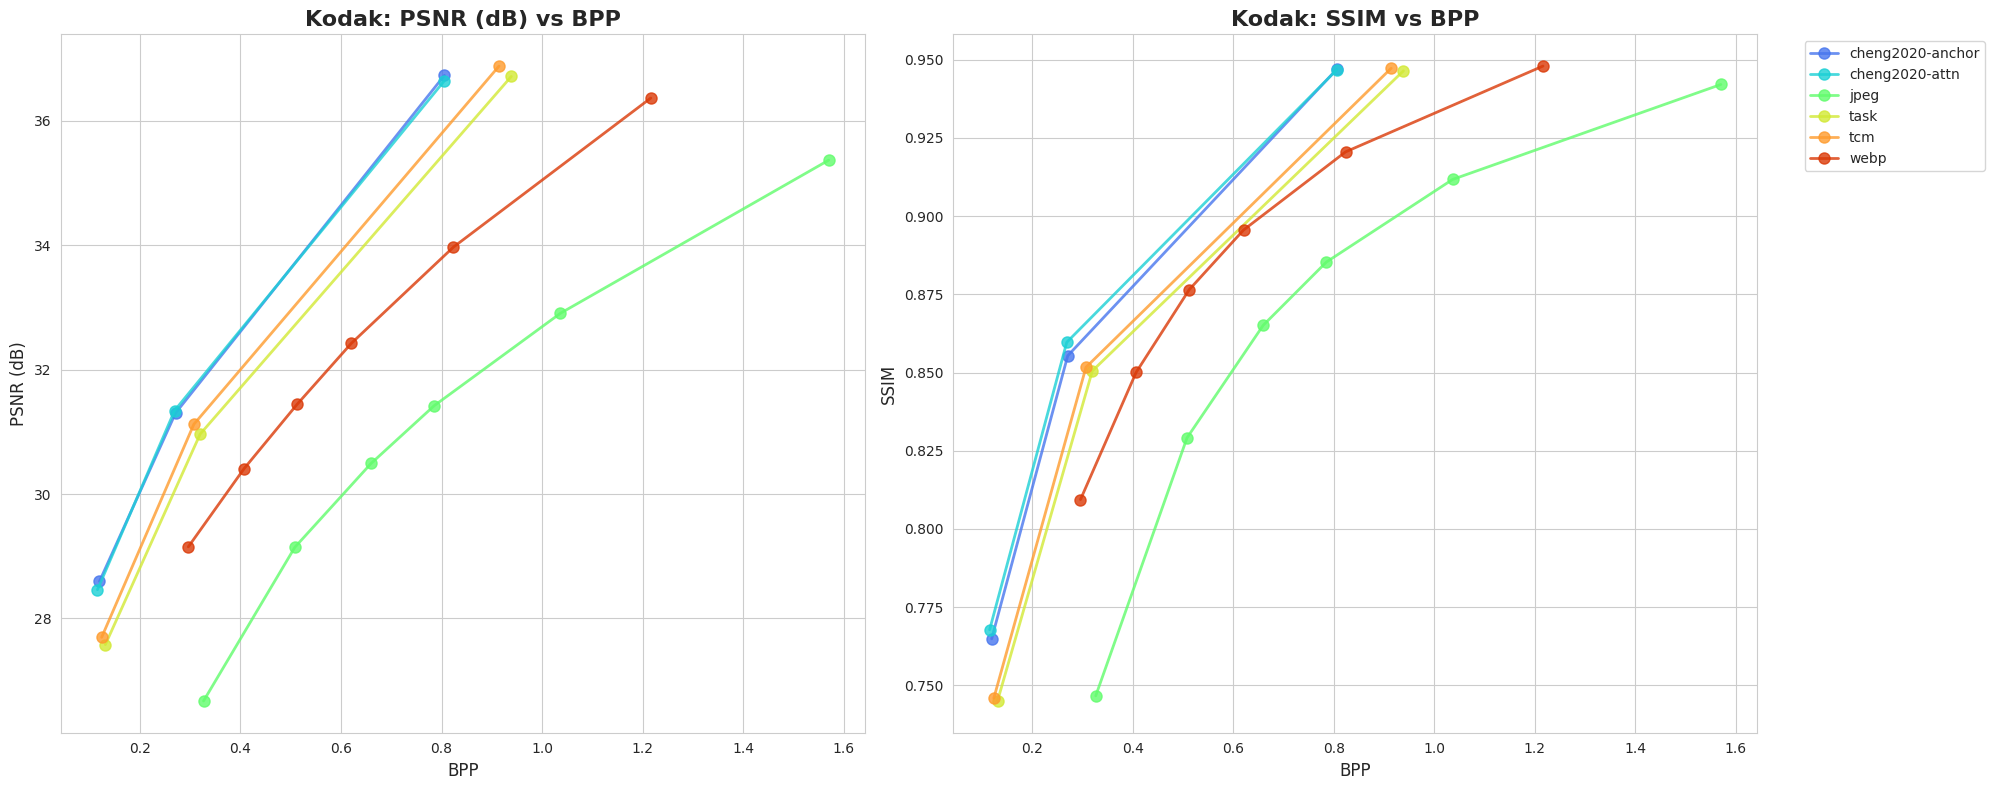

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

available_files = list(METRICS_DIR.glob("*.csv"))

possible_names = ["kodak_fidelity_full_final.csv", "kodak_fidelity_full_results.csv", "kodak_fidelity_summary.csv"]
results_path = None

for name in possible_names:
    if (METRICS_DIR / name).exists():
        results_path = METRICS_DIR / name
        break

if results_path is None:
    print("Error.")
else:
    df = pd.read_csv(results_path)
    
    if 'quality' not in df.columns:
        df['quality'] = 0
        
    df = df.dropna(subset=["bpp", "psnr", "ssim"]).copy()
    print(f"Загружено строк: {len(df)}")
    print(f"Модели в файле: {df['model'].unique()}")

    agg = df.groupby(["model", "quality"], as_index=False).agg(
        avg_bpp=("bpp", "mean"),
        avg_psnr=("psnr", "mean"),
        avg_ssim=("ssim", "mean")
    ).sort_values(["model", "avg_bpp"])

    if agg.empty:
        print("Error")
    else:
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        metrics = [("avg_psnr", "PSNR (dB)"), ("avg_ssim", "SSIM")]
        models = agg['model'].unique()
        palette = sns.color_palette("turbo", n_colors=len(models))

        for i, (m_col, m_name) in enumerate(metrics):
            ax = axes[i]
            for idx, model in enumerate(models):
                model_df = agg[agg['model'] == model]
                ax.plot(model_df['avg_bpp'], model_df[m_col], 
                        label=model, marker='o', markersize=8, linewidth=2, 
                        color=palette[idx], alpha=0.8)

            ax.set_title(f"Kodak: {m_name} vs BPP", fontsize=16, fontweight='bold')
            ax.set_xlabel("BPP", fontsize=12)
            ax.set_ylabel(m_name, fontsize=12)
            if i == 1:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

Обработка: JPEG...
Обработка: WebP...
Обработка: Cheng Anchor...


/tmp/ipykernel_123/786210493.py:53: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  out_enc = model.compress(x_padded)


Обработка: Cheng Attention...
Обработка: TCM Proxy...
Обработка: Task-Aware...


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/plots/comparison_kodim04.png'

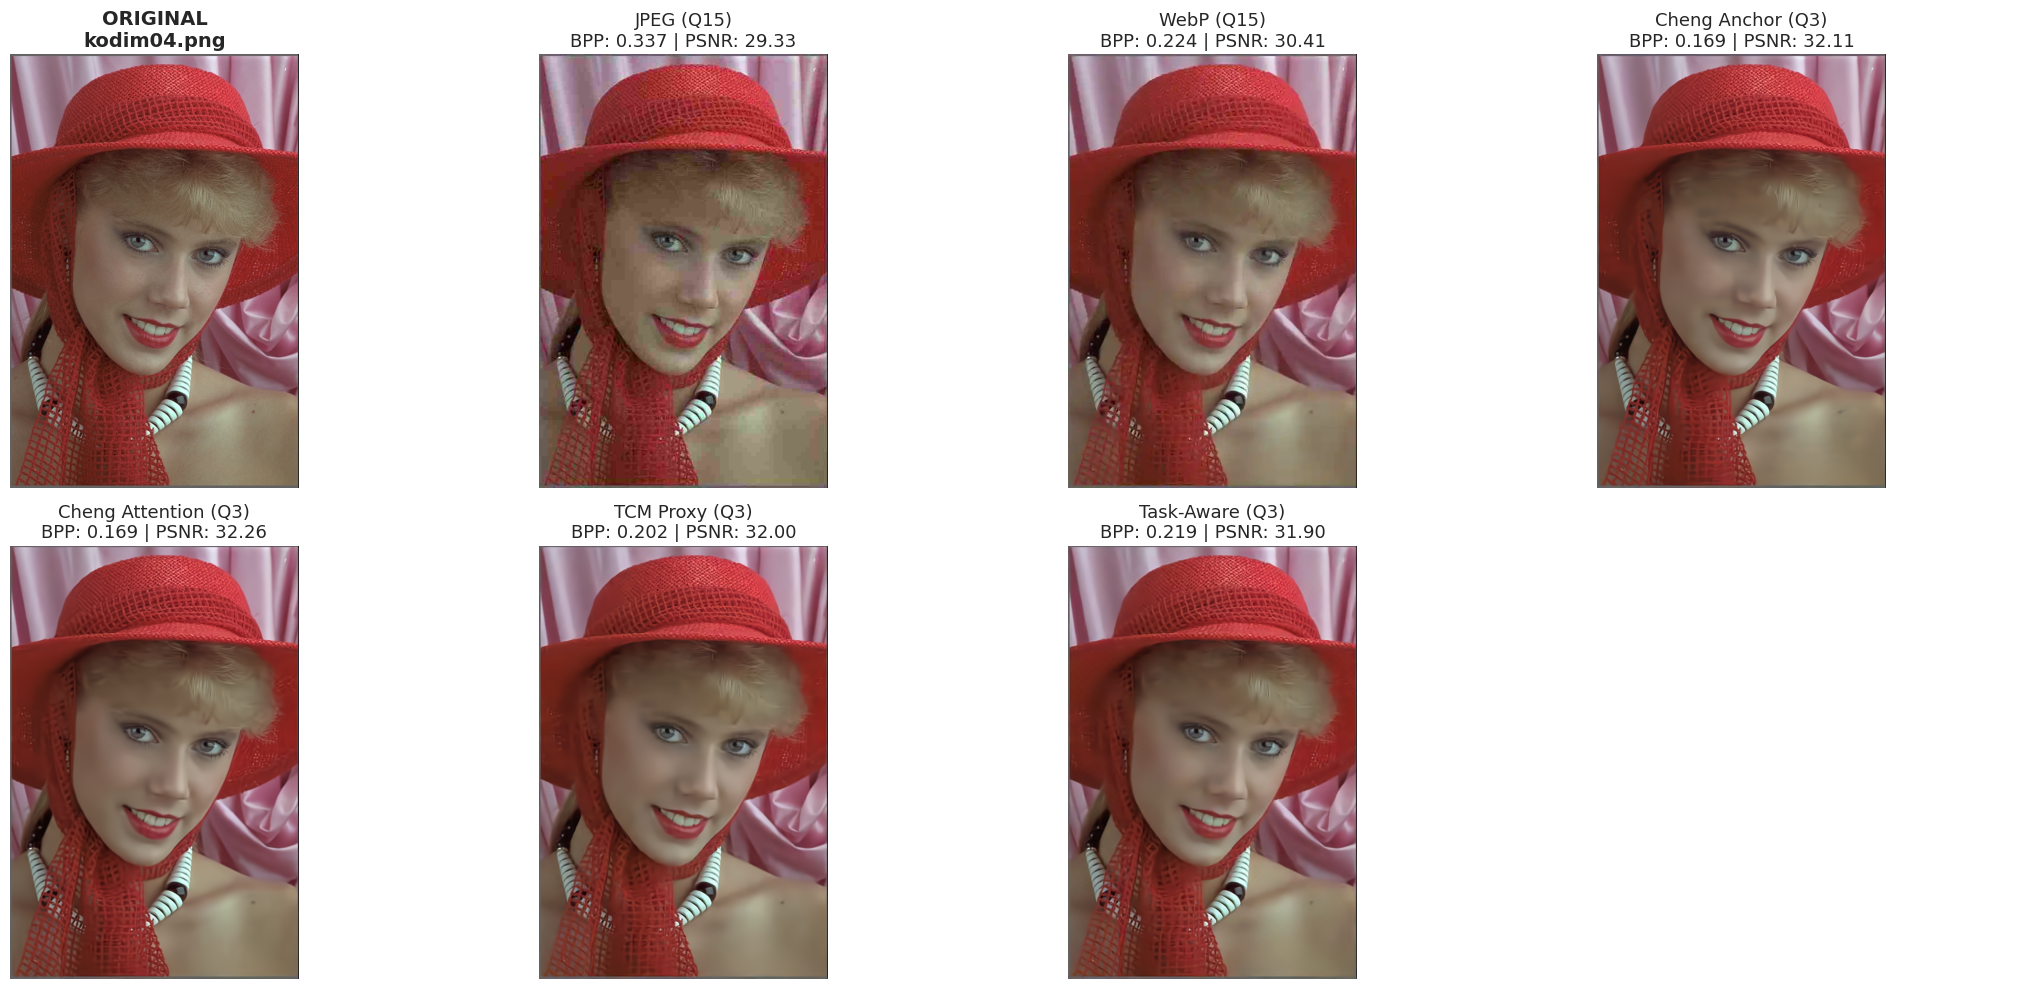

In [10]:
import io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import ToTensor, ToPILImage


def generate_and_plot_single_image(image_name="kodim04.png", q_neural=3, q_classic=20):
    img_path = DATA_DIR / image_name
    if not img_path.exists():
        print(f"File {img_path} not found! Check the name.")
        return

    
    x = ToTensor()(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    _, _, h, w = x.shape
    
    models_to_test = [
        ("jpeg", q_classic, False, "JPEG"),
        ("webp", q_classic, False, "WebP"),
        ("cheng2020-anchor", q_neural, True, "Cheng Anchor"),
        ("cheng2020-attn", q_neural, True, "Cheng Attention"),
        ("tcm", q_neural, True, "TCM Proxy"),
        ("task", q_neural, True, "Task-Aware")
    ]

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    axes[0].imshow(Image.open(img_path).convert("RGB"))
    axes[0].set_title(f"ORIGINAL\n{image_name}", fontsize=14, fontweight='bold')
    axes[0].axis("off")

    for i, (m_name, q, is_neural, label) in enumerate(models_to_test):
        ax = axes[i + 1]
        print(f"Обработка: {label}...")
        
        save_dir = RECON_DIR / m_name / f"q{q}"
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / image_name
        
        if is_neural:
            model = load_compressai_model(m_name, quality=q, metric=METRIC, device=device)
            model.eval()
            
            p = 64
            new_h = (h + p - 1) // p * p
            new_w = (w + p - 1) // p * p
            x_padded = F.pad(x, (0, new_w - w, 0, new_h - h), mode="reflect")
            
            with torch.no_grad():
                out_enc = model.compress(x_padded)
                total_bytes = count_bytes_in_strings(out_enc["strings"])
                
                out_forward = model(x_padded)
                x_hat = out_forward["x_hat"][:, :, :h, :w].clamp(0, 1)
            
            del model
            torch.cuda.empty_cache()
            
        else:
            img_pil = Image.open(img_path).convert("RGB")
            buf = io.BytesIO()
            fmt = "JPEG" if m_name == "jpeg" else "WEBP"
            
            img_pil.save(buf, format=fmt, quality=q)
            total_bytes = buf.tell()
            buf.seek(0)
            
            x_hat = ToTensor()(Image.open(buf)).unsqueeze(0).to(device)

        recon_pil = ToPILImage()(x_hat.squeeze(0).cpu())
        recon_pil.save(save_path)
        
        bpp = (total_bytes * 8) / (h * w)
        psnr, ssim = compute_psnr_ssim(x, x_hat)
        
        ax.imshow(recon_pil)
        ax.set_title(f"{label} (Q{q})\nBPP: {bpp:.3f} | PSNR: {psnr:.2f}", fontsize=13)
        ax.axis("off")

    axes[7].axis("off")
    
    plt.tight_layout()
    
    plot_save_path = OUT_DIR / "plots" / f"comparison_{image_name}"
    plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

generate_and_plot_single_image("kodim04.png", q_neural=3, q_classic=15)